In [17]:
# Import Libraries and load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load data
df = pd.read_csv("dodgers-2022.csv")

## Exploratory Data Analysis
### Data Understanding

In [16]:
# Dataset preview
df.head()

,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO
3,APR,13,31601,Friday,Padres,54,Cloudy,Night,NO,NO,YES,NO
4,APR,14,46549,Saturday,Padres,57,Cloudy,Night,NO,NO,NO,NO


In [18]:
# Column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   month        81 non-null     object
 1   day          81 non-null     int64 
 2   attend       81 non-null     int64 
 3   day_of_week  81 non-null     object
 4   opponent     81 non-null     object
 5   temp         81 non-null     int64 
 6   skies        81 non-null     object
 7   day_night    81 non-null     object
 8   cap          81 non-null     object
 9   shirt        81 non-null     object
 10  fireworks    81 non-null     object
 11  bobblehead   81 non-null     object
dtypes: int64(3), object(9)
memory usage: 7.7+ KB


In [19]:
# Summary statistics for dataset numeric columns
df.describe()

,day,attend,temp
count,81.000000,81.000000,81.000000
mean,16.135802,41040.074074,73.148148
std,9.605666,8297.539460,8.317318
min,1.000000,24312.000000,54.000000
25%,8.000000,34493.000000,67.000000
50%,15.000000,40284.000000,73.000000
75%,25.000000,46588.000000,79.000000
max,31.000000,56000.000000,95.000000


### Data Quality Check

In [20]:
# Check for missing values
df.isna().sum()

month          0
day            0
attend         0
day_of_week    0
opponent       0
temp           0
skies          0
day_night      0
cap            0
shirt          0
fireworks      0
bobblehead     0
dtype: int64

Since there are no missing values, no data cleaning is required for missing values.

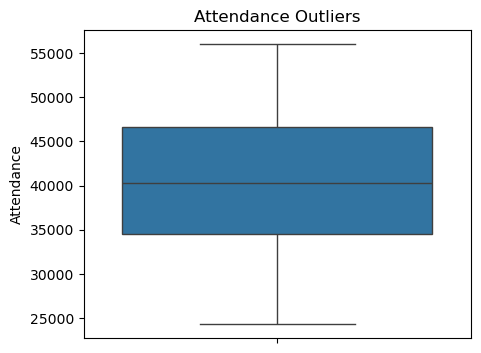

In [21]:
# Check for outliers in attendance, which is the target feature
plt.figure(figsize=(5,4))
sns.boxplot(y=df["attend"])
plt.title("Attendance Outliers")
plt.ylabel("Attendance")
plt.show()

The boxplot shows that most games have attendance between 35,000 and 47,000, with a median around 40,000. A few games have attendance at almost 56,000. That level of attendance is probably the maximum. These are not outliers per se, but because they are at the extreme they may have information that will help us give recommendations.

### Data Visualizations

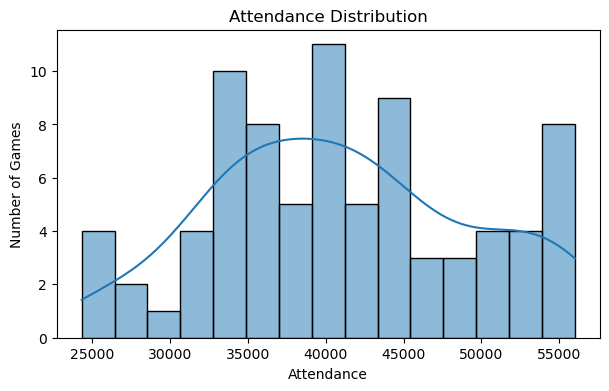

In [24]:
# Attendance distribution
plt.figure(figsize=(7,4))
sns.histplot(df["attend"], bins=15, kde=True)
plt.title("Attendance Distribution")
plt.xlabel("Attendance")
plt.ylabel("Number of Games")
plt.show()

The attendance distribution is right-skewed.  Most games have an attendance between 30,000 and 45,000.  The tail extends all the way up to more than 55,000. The most common attendance is around 40,000 per game.

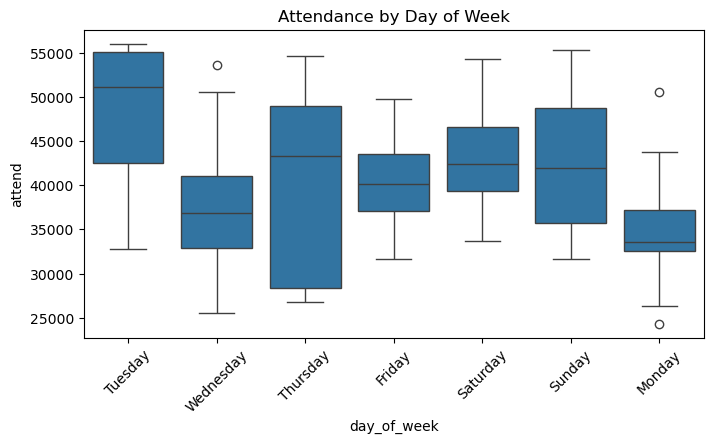

In [25]:
# Attendance by day of week
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="day_of_week", y="attend")
plt.xticks(rotation=45)
plt.title("Attendance by Day of Week")
plt.show()

The boxplot for day of the week attendance shows that Tuesdays have the highest mean attendance and Mondays have the lowest. The other days of the week are relatively close.  There are a few outliers for Monday and Wednesday.

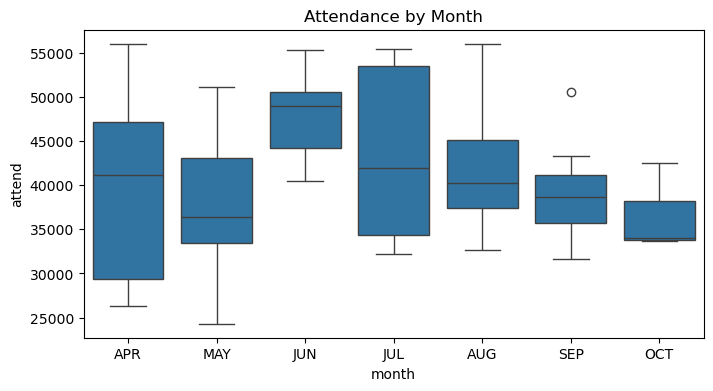

In [26]:
# Attendance by month
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="month", y="attend")
plt.title("Attendance by Month")
plt.show()

The boxplot for monthly attendance shows that the summer month have the higher range and overall higher mean attendance rates. It also shows that the mean tapers off throughout the summer into the early fall months.

## Data Preparation
In prepartion for modeling I will do feature creation.  Knowing if games are on the weekend, at night, or if there was a promotion going on will help to identify events that may have boosted attendance. I will also need to encode the month column so that it can be used to learn seasonal patterns.

In [30]:
# Weekend (Only Saturday or Sunday)
df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)

# Night game
df["is_night"] = (df["day_night"].str.strip() == "Night").astype(int)

# Promotion day
for col in ["cap", "shirt", "fireworks", "bobblehead"]:
    df[col + "_bin"] = (df[col].str.strip() == "YES").astype(int)

# Month number for modeling
month_order = ["APR", "MAY", "JUN", "JUL", "AUG", "SEP", "OCT"]
month_map = {m: i+1 for i, m in enumerate(month_order)}
df["month_num"] = df["month"].map(month_map)


#### Final Dataset Preparation for Modeling
After creating new features, I chose the key variables needed for modeling. I made the dataset fully numeric and made it ready for supervised learning. Since I have been a baseball fan most of my life I think that the oppenent matters alot, so I will do one-hot encoding for the opponent and include it in the modeling and analysis.

In [32]:
# Import libraries for model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Assign the features to a list 
features = [ "temp", "month_num", "day", "is_weekend", "is_night", "cap_bin", "shirt_bin", "fireworks_bin", "bobblehead_bin" ]

# One-hot encoding for opponent
df_model = pd.get_dummies(df, columns=["opponent"], drop_first=True)

# Adding opponent columns to the feature list
opponent_cols = [c for c in df_model.columns if c.startswith("opponent_")] 
features += opponent_cols

# Define the X and y variables for the model
X = df_model[features]
y = df_model["attend"]

In [33]:
# Model Training

# Assigning training and testing sets from the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the linear regreassion model and train it
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions for the test set
y_pred = model.predict(X_test)

# Evaluate the model with R2 and MAE
print("R^2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))



R^2 Score: 0.13209357196786198
MAE: 7006.480320991126


In [36]:
# Model Interpretation - creating coeffienct table from my model
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
}).sort_values(by="coefficient", key=abs, ascending=False)
coef_df

,feature,coefficient
8,bobblehead_bin,16768.976201
20,opponent_Pirates,-13422.982573
9,opponent_Astros,-12476.688971
11,opponent_Brewers,-11032.896682
10,opponent_Braves,-10959.334578
23,opponent_Snakes,-10345.033419
18,opponent_Padres,-9756.904701
22,opponent_Rockies,-9400.977208
15,opponent_Marlins,-8506.795111
12,opponent_Cardinals,-7944.609861


### Findings and Recommendations

After I trained the linear regression model, I reviewed the feature coefficients to know which factors had the most influence on attendance. The coefficients show how much promotions, opponents, and scheduling matter for attendance.

My important findings include:
    Bobblehead giveaways have the biggest impact on attendance.  The average increase is more than 16,000.
    Shirt and fireworks also increase attendance, but nowhere near the amount of the bobblehead giveaways. The average increase for these is only about 5,000 each.
    Weekend games do draw about 3,000 more fans versus weekday games.
    Night games do have a slightly lower attendance on average when compared to day games.
    A few opponents do tend to lower the attendance quite significantly. Specifically the Pirates, Astros, and Brewers lower attendance by 11,000 to 13,000. 

As we are looking to increase overall attendance, the best strategy is to focus on the games that have lower attendance. Based on the model results, I recommend increasing bobblehead giveaways, especially against teams such as the Pirates, Astros, and Brewers. I also recommend pairing shirt giveaways on weekday night games and fireworks displays against mid-range attendance opponents, like the Braves, Snakes, and Padres. Adding these combinations can help increase attendance for the games that draw a smaller crowd.

The data shows that promotions are the most effective tool in increasing attendance. If you use them strategically for the lower attendance games, I believe we can increase the average attendance across all games.